In [1]:
# /// script
# requires-python = ">=3.12"
# dependencies = [
#     "bioio",
#     "bioio-nd2",
#     "imageio",
#     "matplotlib",
#     "ndv[jupyter,vispy]",
#     "jupyter-rfb<=0.5.4",
#     "numpy",
#     "rich",
#     "tifffile",
# ]
# ///

In [2]:
import matplotlib.pyplot as plt
import ndv
import numpy as np
import tifffile
from bioio import BioImage
from rich import print

In [3]:
stack_path = "../../_static/images/python4bia/confocal-series.tif"  # Specify the path to the image
stack = tifffile.imread(stack_path)  # read stack_path and store it in stack

print(type(stack))
print(stack.dtype)
print(stack.shape)

<class 'numpy.ndarray'>

uint8

(25, 2, 400, 400)

In [ ]:
ndv.imshow(stack)

In [4]:
viewer = ndv.imshow(stack)

RFBOutputContext()

<IPython.core.display.Javascript object>

RFBOutputContext()

RFBOutputContext()


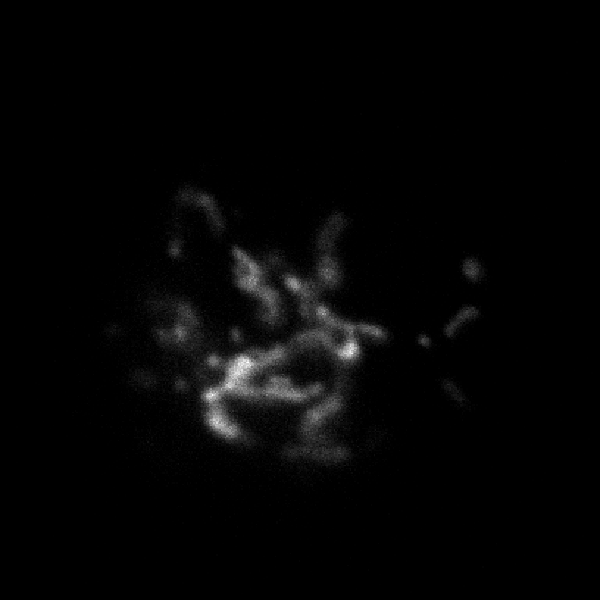

In [5]:
viewer.widget().children[1].snapshot()

In [6]:
cat_img_path = "../../_static/images/python4bia/cateye_nonsquare_ds.tif"
cat = tifffile.imread(cat_img_path)

In [7]:
type(cat)

numpy.ndarray

In [8]:
cat

array([[217, 176, 226, 253, 150, 226, 228, 220, 210, 218, 224],
       [215, 181, 236, 219, 225, 220, 215, 210, 141, 173, 105],
       [199, 140, 231, 222, 228, 238, 218, 194, 195, 197,  34],
       [206, 202, 236, 240, 213, 218, 192, 249, 244, 240,  52],
       [226, 220, 235, 202, 188,  50, 226, 242, 233, 224,  49],
       [238, 247, 208, 179, 234,  91, 181, 227, 237, 140,  45],
       [230, 164, 234, 176, 182, 233, 237, 209, 176,  51, 192],
       [246,  86, 204, 218, 199, 202, 230, 208,  51,  61, 222],
       [251,  34, 150, 201, 198, 223, 157,  57,  56, 239, 101],
       [249, 131, 111,  62,  48,  53,  67, 110, 223, 129, 140],
       [253, 148, 169, 184, 150, 182, 197, 236, 206, 142, 197],
       [253, 175, 202, 222, 253, 251, 234, 185, 165, 144, 164]],
      dtype=uint8)

In [9]:
print(cat)

[[217 176 226 253 150 226 228 220 210 218 224]
 [215 181 236 219 225 220 215 210 141 173 105]
 [199 140 231 222 228 238 218 194 195 197  34]
 [206 202 236 240 213 218 192 249 244 240  52]
 [226 220 235 202 188  50 226 242 233 224  49]
 [238 247 208 179 234  91 181 227 237 140  45]
 [230 164 234 176 182 233 237 209 176  51 192]
 [246  86 204 218 199 202 230 208  51  61 222]
 [251  34 150 201 198 223 157  57  56 239 101]
 [249 131 111  62  48  53  67 110 223 129 140]
 [253 148 169 184 150 182 197 236 206 142 197]
 [253 175 202 222 253 251 234 185 165 144 164]]

In [10]:
print(f"Type of the image: {type(cat)}")
print(f"Datatype of the image: {cat.dtype}")
print(f"Shape of the image: {cat.shape}")  # Dimensions of the image
print(f"Minimum pixel value: {cat.min()}")  # Min pixel value
print(f"Maximum pixel value: {cat.max()}")  # Max pixel value
print(f"Mean pixel value: {cat.mean():.2f}")  # Average pixel value

Type of the image: <class 'numpy.ndarray'>

Datatype of the image: uint8

Shape of the image: (12, 11)

Minimum pixel value: 34

Maximum pixel value: 253

Mean pixel value: 184.17

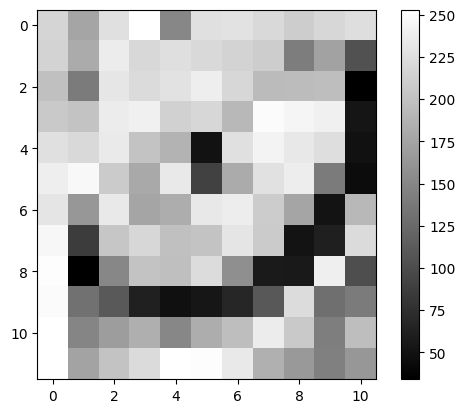

In [11]:
plt.imshow(cat, cmap="gray")
plt.colorbar()
plt.show()

In [12]:
def simpleplot(image: np.ndarray) -> None:
    """
    Plot `image` in grayscale with an accompanying colorbar.

    Parameters
    ----------
    image : A 2D np.ndarray
    """
    plt.imshow(image, cmap="gray")
    plt.colorbar()
    plt.show()

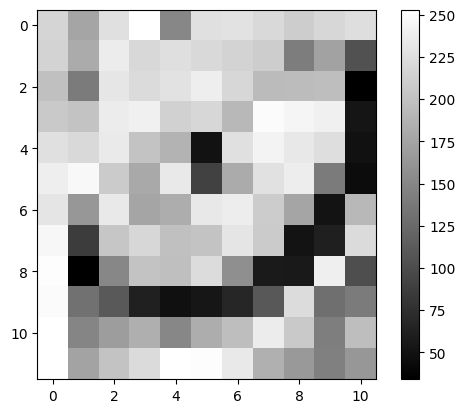

In [13]:
simpleplot(cat)

In [14]:
def valueplot(image: np.ndarray, indices: str = "empty", fontsize: int = 10) -> None:
    """
    Show a 2-D array as a grayscale heat-map, print each pixel's value on top,
    and optionally outline pixels or regions.

    Parameters
    ----------
    image : np.ndarray
        Array of shape (rows, cols).
    indices : str, optional
        String with numpy indexing notation using either brackets [] or parentheses ().

        Examples:
        - "(5, 3)" or "[5, 3]" - single pixel
        - "[0:5, 3:7]" or "(0:5, 3:7)" - region from rows 0-4, columns 3-6
        - "(:, 0)" or "[:, 0]" - entire column 0
        - "(2, :)" or "[2, :]" - entire row 2
        - "[:,:]" - entire image
        - "[::2, 1::3]" - every 2nd row, every 3rd column starting from column 1
    """

    if indices == "empty":
        indices = "[0:0, 0:0]"

    def parse_index_string(index_str: str) -> tuple:
        """Parse numpy-style indexing string into tuple of slices/ints."""
        # Remove brackets and parentheses
        index_str = index_str.strip()
        if index_str.startswith("[") and index_str.endswith("]"):
            index_str = index_str[1:-1]
        elif index_str.startswith("(") and index_str.endswith(")"):
            index_str = index_str[1:-1]

        # Split by comma
        parts = [part.strip() for part in index_str.split(",")]

        if len(parts) != 2:
            raise ValueError(
                "Index string must have exactly 2 parts separated by comma"
            )

        result = []
        for part in parts:
            if part == ":" or part == "":
                # Full slice
                result.append(slice(None))
            elif ":" in part:
                # Parse slice notation
                slice_parts = part.split(":")
                start = None if slice_parts[0] == "" else int(slice_parts[0])
                stop = (
                    None
                    if len(slice_parts) < 2 or slice_parts[1] == ""
                    else int(slice_parts[1])
                )
                step = (
                    None
                    if len(slice_parts) < 3 or slice_parts[2] == ""
                    else int(slice_parts[2])
                )
                result.append(slice(start, stop, step))
            else:
                # Single integer
                result.append(int(part))

        return tuple(result)

    if indices is None:
        indices = [None, None]
    else:
        # Parse string notation
        indices = parse_index_string(indices)

    plt.imshow(image, cmap="gray", vmin=np.min(image), vmax=np.max(image))

    # Annotate each pixel with its value
    for i in range(image.shape[0]):  # row
        for j in range(image.shape[1]):  # column
            plt.text(
                j,
                i,
                str(image[i, j]),
                ha="center",
                va="center",
                color="magenta",
                fontsize=fontsize,
            )

    plt.ylabel("row; y; axis = 0", fontsize=fontsize)
    plt.xlabel("column; x; axis = 1", fontsize=fontsize)

    # Handle different types of indices
    if indices is not None and len(indices) == 2:
        row_idx, col_idx = indices

        # Convert indices to ranges for highlighting
        if isinstance(row_idx, slice):
            # Handle slice objects
            start_row = row_idx.start if row_idx.start is not None else 0
            stop_row = row_idx.stop if row_idx.stop is not None else image.shape[0]
            step_row = row_idx.step if row_idx.step is not None else 1

            if start_row < 0:
                start_row = image.shape[0] + start_row
            if stop_row < 0:
                stop_row = image.shape[0] + stop_row
            row_range = list(range(start_row, min(stop_row, image.shape[0]), step_row))
        elif isinstance(row_idx, int):
            # Single row
            if row_idx < 0:
                row_idx = image.shape[0] + row_idx
            row_range = [row_idx] if 0 <= row_idx < image.shape[0] else []
        else:
            row_range = list(range(image.shape[0]))  # All rows if None or invalid

        if isinstance(col_idx, slice):
            # Handle slice objects
            start_col = col_idx.start if col_idx.start is not None else 0
            stop_col = col_idx.stop if col_idx.stop is not None else image.shape[1]
            step_col = col_idx.step if col_idx.step is not None else 1

            if start_col < 0:
                start_col = image.shape[1] + start_col
            if stop_col < 0:
                stop_col = image.shape[1] + stop_col
            col_range = list(range(start_col, min(stop_col, image.shape[1]), step_col))
        elif isinstance(col_idx, int):
            # Single column
            if col_idx < 0:
                col_idx = image.shape[1] + col_idx
            col_range = [col_idx] if 0 <= col_idx < image.shape[1] else []
        else:
            col_range = list(range(image.shape[1]))  # All columns if None or invalid

        # Highlight the region
        for row in row_range:
            for col in col_range:
                rect = plt.Rectangle(
                    (col - 0.5, row - 0.5),
                    1,
                    1,
                    linewidth=2,
                    edgecolor="yellow",
                    facecolor="none",
                )
                plt.gca().add_patch(rect)

    plt.yticks(list(range(image.shape[0])))
    plt.xticks(list(range(image.shape[1])))
    plt.tight_layout()
    plt.show()

Text(0, 0.5, 'count')

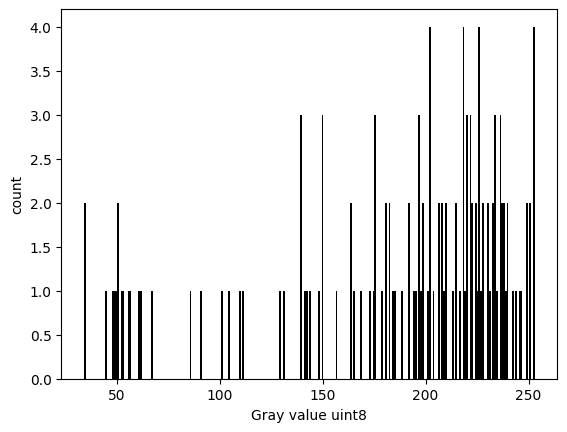

In [15]:
plt.hist(cat.ravel(), bins=256, color="k")
plt.xlabel(f"Gray value {cat.dtype}")  # format string
plt.ylabel("count")

In [16]:
# Pass numbers directly
print(cat[0, 10])

224

In [17]:
# Define variables
row, col = 0, 10
print(cat[row, col])

224

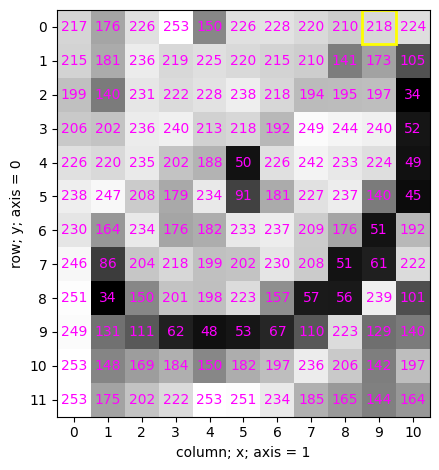

In [18]:
row, col = 0, -2
valueplot(cat, indices=str([row, col]))

In [19]:
row = 1
print(cat[row, :])  #
print(cat[row,])  # This is equivalent to the above
print(cat[row])  # If only one number is supplied, it applies to axis 0

[215 181 236 219 225 220 215 210 141 173 105]

[215 181 236 219 225 220 215 210 141 173 105]

[215 181 236 219 225 220 215 210 141 173 105]

In [20]:
# print(cat[1, ]) # Tries to print the first row
# print(cat[, 1]) # Tries to print the first column

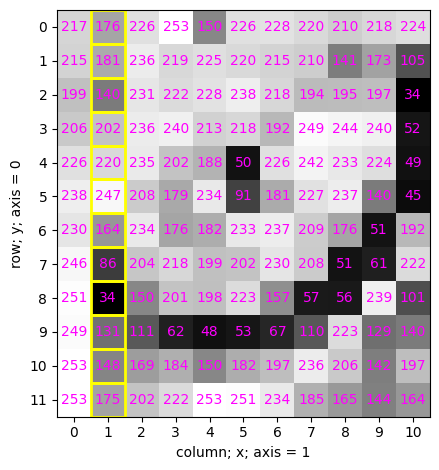

In [21]:
valueplot(cat, indices="[:, 1]")

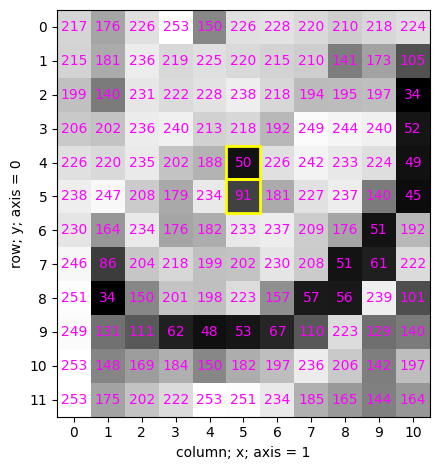

In [22]:
valueplot(cat, "[4:6, 5]")

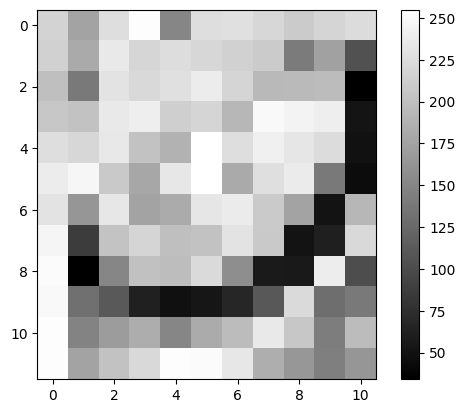

In [23]:
### Pitfall
lazercat = cat
lazercat[4:6, 5] = 255
simpleplot(cat)

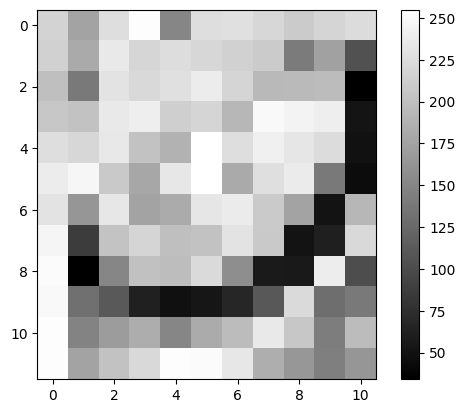

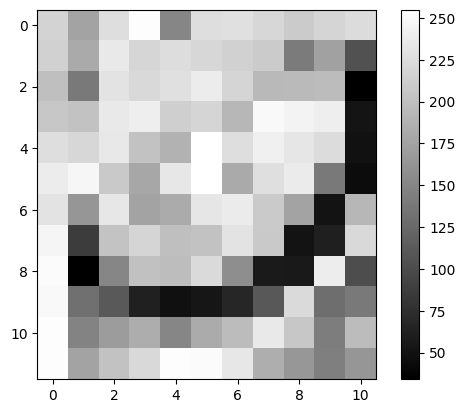

In [24]:
simpleplot(cat)
simpleplot(lazercat)

In [25]:
# reload cat in case it was overwritten
def load_cat(cat_img_path) -> np.ndarray:
    cat = tifffile.imread(cat_img_path)
    return cat


cat = load_cat(cat_img_path)

In [26]:
lazercat = cat.copy()
lazercat[4:6, 5] = 255

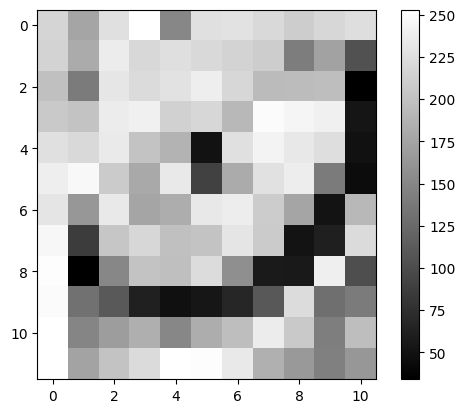

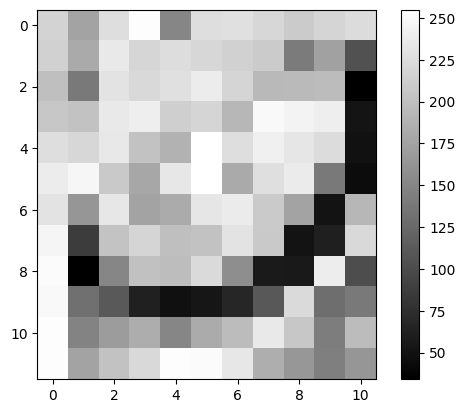

In [27]:
simpleplot(cat)
simpleplot(lazercat)

In [28]:
# cat = load_cat(cat_img_path) # Run if you accidentally overwrote ```cat```

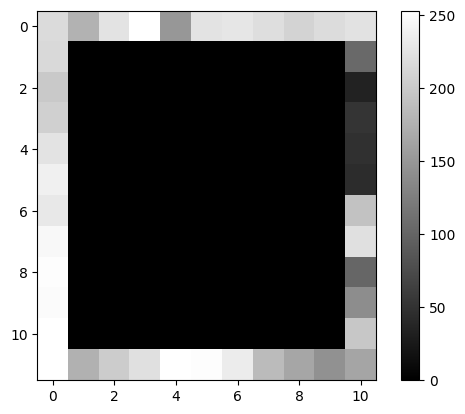

In [29]:
pirate = cat.copy()
pirate[1:-1, 1:-1] = 0
simpleplot(pirate)

In [30]:
monocle_bool = np.array(cat, dtype=bool)
monocle_bool[0, :] = False
monocle_bool[-1, :] = False
monocle_bool[:, 0] = False
monocle_bool[:, -1] = False
monocle_bool = ~monocle_bool

bool

(12, 11)

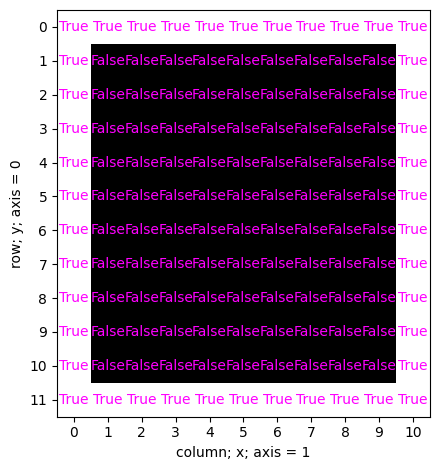

In [31]:
print(monocle_bool.dtype)
print(monocle_bool.shape)
valueplot(monocle_bool)

In [32]:
# cat = load_cat(cat_img_path) # Run if you accidentally overwrote ```cat```

In [33]:
monocle = cat.copy()

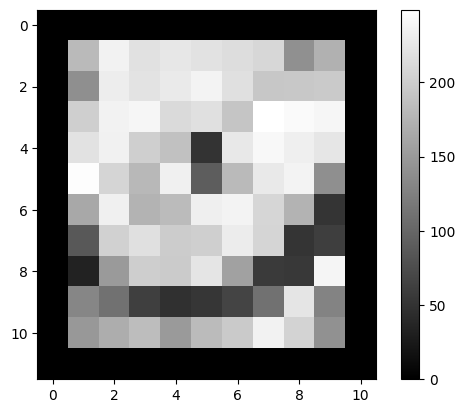

In [34]:
monocle[monocle_bool] = 0  # Set rim pixels to 0
simpleplot(monocle)

In [35]:
# Here, we define a function to read the stack from a specified path
def read_stack(
    path: str = stack_path,
) -> np.ndarray:
    stack = tifffile.imread(path)
    return stack

In [36]:
stack = read_stack(
    stack_path
)  # reloads image "stack". Run this if you accidentally overwrote `stack`

In [37]:
print(stack.dtype)
print(stack.shape)

uint8

(25, 2, 400, 400)

In [ ]:
ndv.imshow(stack)

In [38]:
viewer = ndv.imshow(stack)

RFBOutputContext()

<IPython.core.display.Javascript object>


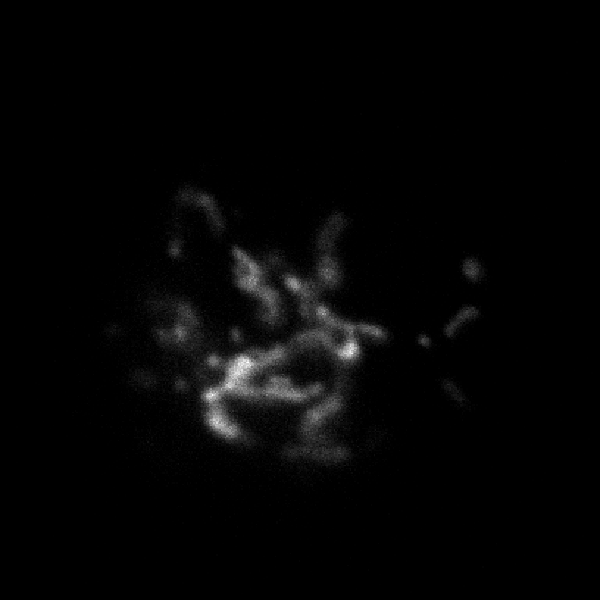

In [39]:
viewer.widget().children[1].snapshot()

In [40]:
# Reminder
stack.shape

(25, 2, 400, 400)

In [41]:
ch0 = stack[:, 0].copy()
ch1 = stack[:, 1].copy()

In [42]:
print(ch0.shape)

(25, 400, 400)

In [43]:
## Pitfall:
# simpleplot(ch0)

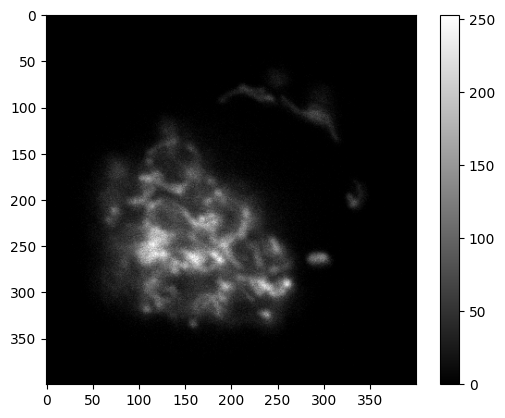

In [44]:
# simpleplot can only plot a 2D array.
# You must index ch0 such that it returns a 2D array. Examples:
z = 17

simpleplot(ch0[z])  # show only one z-plane

In [45]:
# mean_project_ch0 = ...  # fill in the gaps
# print(mean_project_ch0.shape)
# simpleplot(mean_project_ch0)

(400, 400)

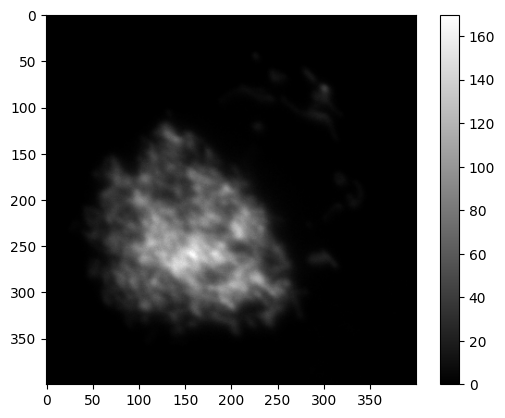

In [46]:
mean_project_ch0 = np.mean(ch0, axis=0)
print(mean_project_ch0.shape)
simpleplot(mean_project_ch0)

(400, 400)

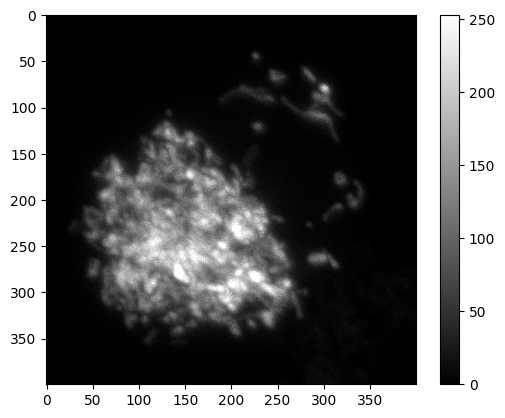

In [47]:
max_project_ch0 = np.max(ch0, axis=0)
print(max_project_ch0.shape)
simpleplot(max_project_ch0)

In [48]:
# Write your code here

In [49]:
zero_array = np.zeros([5, 5])
print(zero_array)
zero_array.dtype

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]

dtype('float64')

In [50]:
zeroes_cat = np.zeros_like(cat)

In [51]:
print(zeroes_cat)
print(zeroes_cat.shape)
print(zeroes_cat.dtype)

[[0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0]]

(12, 11)

uint8

In [52]:
?np.random.randint
# dual_ch_fake = np.random.randint(..., dtype=np.uint8))

In [53]:
dual_ch_fake = np.random.randint(0, 256, size=(2, 9, 10), dtype=np.uint8)

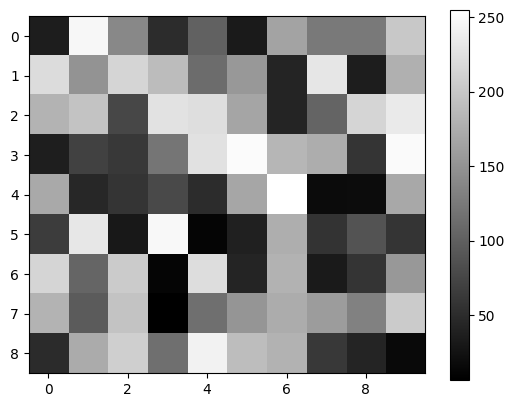

In [54]:
simpleplot(dual_ch_fake[0, :, :])

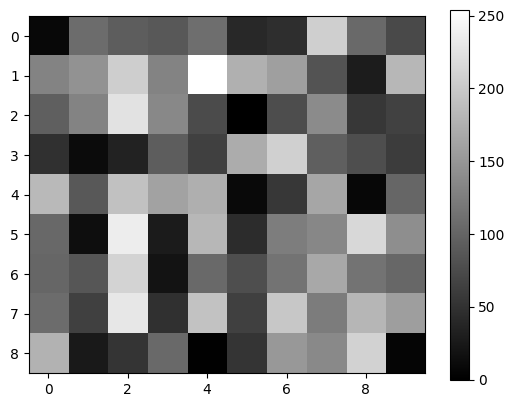

In [55]:
simpleplot(dual_ch_fake[1, :, :])

In [56]:
mean_of_channels = np.mean(dual_ch_fake, axis=0)

In [57]:
ch_0 = dual_ch_fake[0, :, :].copy()
ch_1 = dual_ch_fake[1, :, :].copy()

In [58]:
a = 5
b = 5
a == b

True

In [59]:
### Pitfall
mean_of_channels == (ch_0 + ch_1) / 2  # integer overflow

array([[ True, False,  True,  True,  True,  True,  True, False,  True,
        False],
       [False, False, False, False, False, False,  True, False,  True,
        False],
       [False, False, False, False, False,  True,  True,  True, False,
        False],
       [ True,  True,  True,  True, False, False, False, False,  True,
        False],
       [False,  True,  True,  True,  True,  True, False,  True,  True,
        False],
       [ True,  True, False, False,  True,  True, False,  True, False,
         True],
       [False,  True, False,  True, False,  True, False,  True,  True,
        False],
       [False,  True, False,  True, False,  True, False, False, False,
        False],
       [ True,  True, False,  True,  True,  True, False,  True,  True,
         True]])

In [60]:
### Possible solution:
mean_manual = dual_ch_fake[0, :, :] / 2 + dual_ch_fake[1, :, :] / 2
print(mean_of_channels == mean_manual)
print(np.unique(mean_of_channels == mean_manual))

[[ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]
 [ True  True  True  True  True  True  True  True  True  True]]

[ True]

In [61]:
def show_2_channels(image: np.ndarray, figsize: tuple = (6, 3)) -> None:
    """
    Show a 2-channel image with each channel in a separate subplot.
    Parameters
    ----------
    image : np.ndarray
        A 3D array of shape (2, height, width) representing a 2-channel image.
    Each channel is expected to be a 2D array of pixel values.
    """
    fig, axes = plt.subplots(1, 2, figsize=figsize)

    for i in range(2):
        im = axes[i].imshow(image[i, :, :], cmap="gray", vmin=0, vmax=255)
        axes[i].imshow(image[i, :, :], cmap="gray", vmin=0, vmax=255)
        axes[i].set_title(f"Channel {i}")
        axes[i].axis("off")
        # Add colorbar for this subplot
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

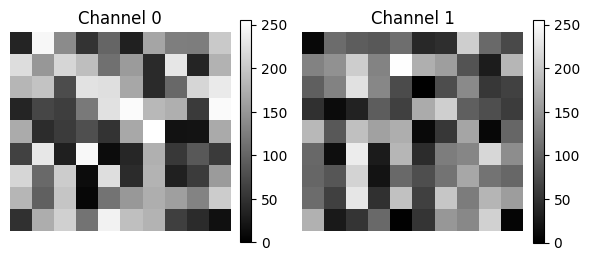

In [62]:
show_2_channels(dual_ch_fake)

In [63]:
threechannel = np.random.randint(0, 256, size=(3, 5, 5), dtype=np.uint8)

In [64]:
threechannel.shape

(3, 5, 5)

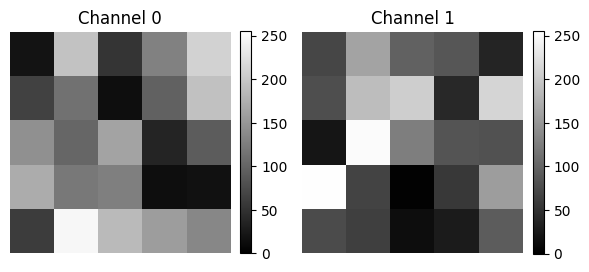

In [65]:
# This works, but it will only show the first two channels.
show_2_channels(threechannel)

In [66]:
def show_all_channels(
    image: np.ndarray, nchannels: int | None = None, figsize: tuple = (6, 3)
) -> None:
    """
    Show all channels of a multi-channel image.
    Parameters
    ----------
    image : np.ndarray
        A 3D array of shape (nchannels, height, width) representing a multi-channel image.
    Each channel is expected to be a 2D array of pixel values.
    nchannels : int, optional
        The number of channels in the image. If None, it will be inferred from the shape
        of the image.
    figsize : tuple, optional
        The size of the figure to display the channels. Default is (6, 3).
    """
    if not nchannels:
        nchannels = image.shape[0]

    fig, axes = plt.subplots(1, nchannels, figsize=figsize)
    for i in range(nchannels):
        vmax = np.max(image[i, :, :])
        vmin = np.min(image[i, :, :])
        im = axes[i].imshow(
            image[i, :, :],
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
        )
        axes[i].imshow(image[i, :, :], cmap="gray", vmin=vmin, vmax=vmax)
        axes[i].set_title(f"Channel {i}")
        axes[i].axis("off")

        # Add colorbar for this subplot
        fig.colorbar(im, ax=axes[i], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.show()

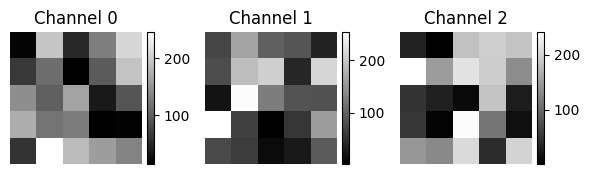

In [67]:
show_all_channels(threechannel)

In [68]:
nd2_path = "../../_static/images/python4bia/single_pos_002.nd2"
img = BioImage(nd2_path)

In [69]:
type(img)

bioio.bio_image.BioImage

In [70]:
print(img.dims.order)
print(img.dims)
print(img.shape)

TCZYX

<Dimensions [T: 1, C: 3, Z: 1, Y: 2044, X: 2048]>

(1, 3, 1, 2044, 2048)

In [71]:
# the image is contained in img.data
cells = img.data

In [72]:
type(cells)  # verify it's a numpy array

numpy.ndarray

In [73]:
cells.dtype  # check the datatype

dtype('uint16')

In [74]:
print(img.dims)  # Reminder:
print(cells.shape)  # only one time-point. This is like a movie with only one frame!

<Dimensions [T: 1, C: 3, Z: 1, Y: 2044, X: 2048]>

(1, 3, 1, 2044, 2048)

In [75]:
simple_list = [1, 2, 3]
simple_array = np.array(simple_list)  # Turn the list into a numpy array

# print a few properties of simple_array
print(type(simple_array))
print(simple_array)
print(simple_array.shape)

<class 'numpy.ndarray'>

[1 2 3]

(3,)

In [76]:
nested_list = [[1, 2, 3]]  # There's extra brackets!
nested_array = np.array(nested_list)

# print a few properties of nested_array
print(type(simple_array))
print(nested_array)
print(nested_array.shape)

<class 'numpy.ndarray'>

[[1 2 3]]

(1, 3)

In [77]:
nested_array_squeezed = nested_array.squeeze()

# print a few properties of nested_array_squeezed
print(type(nested_array_squeezed))
print(nested_array_squeezed)
print(nested_array_squeezed.shape)

<class 'numpy.ndarray'>

[1 2 3]

(3,)

In [78]:
cells = cells.squeeze()
print(cells.shape)

(3, 2044, 2048)

In [79]:
# previously, we ran show_all_channels() on threechannel. Compare cells and threechannel:
print(cells.shape)
print(cells.dtype)
print(threechannel.shape)
print(threechannel.dtype)

(3, 2044, 2048)

uint16

(3, 5, 5)

uint8

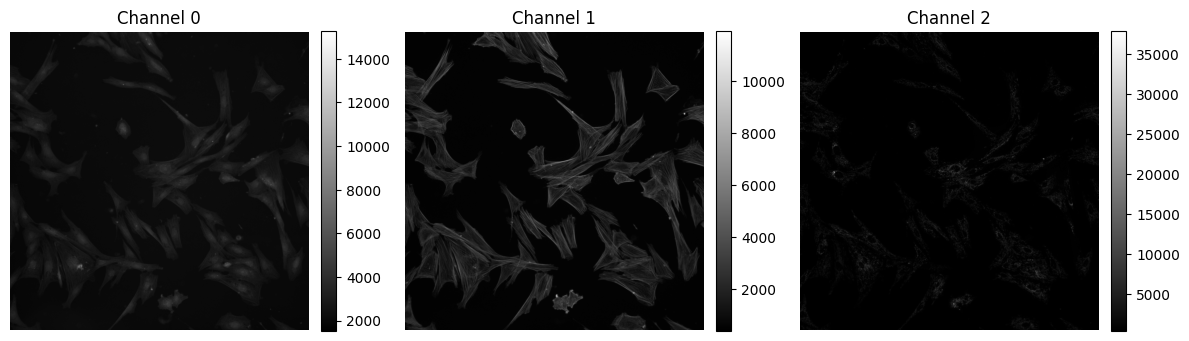

In [80]:
show_all_channels(cells, figsize=(12, 6))